# W02 Sequence & RL Scaffolding

Platform: Aido Rover
Seed: 42
Sampling rate: 10 Hz

Objectives:
1. Sequence tensor — sliding-window `[N, window, channels]` raw view (window ∈ {10, 20, 50}) plus a
   parallel windowed FFT-feature view, under the canonical block split. Built from the continue-policy detection stream (`synthetic_rover_data.csv`).
2. MDP / offline-RL transition table — formal state, action, reward definition; a scripted behaviour policy is
   rolled through the shared world core (blockages ON) to log `(s, a, r, s')` →
   `rover_transitions.csv`, `mdp_schema.md`.

Both artefacts feed Phase B (sequence models, W03) and Phase C (RL environment, W05). The transition table is
generated by the same RoverWorld the W05 env wraps, so the offline data and the online env share identical
dynamics. Design rationale: `reports/W02_RL_scaffold.md`.


In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.fft import rfft, rfftfreq

SEED = 42
np.random.seed(SEED)

sys.path.insert(0, str(Path.cwd().parent))   # repo root, to import the shared world core / feature module
from shared_modules.rover_world import RoverWorld
from shared_modules.features import add_gps_deltas, physical_channels, fft_features

DATA_DIR = Path('../data')
df_raw = pd.read_csv(DATA_DIR / 'synthetic_rover_data.csv', index_col='timestamp', parse_dates=True)
df = df_raw.ffill().bfill()

ACTION_NAMES = {0: 'continue', 1: 'slow', 2: 'reroute',
                3: 'raise-alert', 4: 'return-to-base'}

## 1. Sliding-Window Sequence Tensor

### Split strategy

Anchor rows and their train/val/test membership come from `data/rover_stratified_block_split.csv`, every model is compared on identical rows.

Window label = anomaly_label at timestep t (end of window). GPS is fed as per-step deltas (`gps_dlat`,
`gps_dlon`), matching the preprocessing pipeline — absolute position is a fixed-map shortcut, not a
transferable fault signal. Two cross-channel physical features — `inter_wheel_std` (slip: one wheel
diverging from the rest) and `stall_ratio` (stuck: torque without displacement), from
`shared_modules/features.py` — are added as extra raw channels (11 total).

### Window-size sweep

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| WINDOW | {10, 20, 50} steps | Three window sizes are built from the same anchor rows (the purge is fixed at 50 regardless of which window a given model consumes), so the W03 latency-vs-window-size and data-efficiency analyses compare window size alone, not window size confounded with a different row set. 50 steps (5 s) matches the FFT window; 10/20 are the shorter alternatives Week 3 tests against the anomaly-duration distribution. |
| STRIDE | 1 step (0.1 s) | Dense stride maximises training samples; every anomaly onset is captured. Phase B models can subsample if compute is a concern. |

### Parallel FFT-feature view

Alongside the raw `[window, 11]` tensors, a windowed FFT-feature view (window=50, matching the preprocessing
pipeline) is built over the same split, 5 spectral features(frequency, centroid, bandwidth, total
power, peak-to-mean), torque channels + LiDAR. Row-for-row aligned with the window tensors (same
anchor rows), so Phase B models can train on the raw tensor, the FFT view, or both without re-deriving splits.

In [2]:
WINDOW_SIZES = [10, 20, 50]
WINDOW_MAX   = 50        # must match the purge width in W02_Preprocessing_Pipeline.ipynb
WINDOW       = WINDOW_MAX  # Section 2 (MDP state extraction) reuses this name for its own look-back
STRIDE       = 1         # step size between consecutive anchors
FS           = 10.0      # Hz
N_CHANNELS   = 11        # 9 raw (GPS-delta) + 2 physical (inter_wheel_std, stall_ratio)

df = add_gps_deltas(df)
df['inter_wheel_std'], df['stall_ratio'] = physical_channels(df)
SENSOR_COLS = [
    'gps_dlat', 'gps_dlon', 'lidar_distance', 'battery_soc',
    'torque_0', 'torque_1', 'torque_2', 'torque_3', 'ambient_temp',
    'inter_wheel_std', 'stall_ratio']

TORQUE_COLS = ['torque_0', 'torque_1', 'torque_2', 'torque_3']

# ── Load the canonical block split (built once in W02_Preprocessing_Pipeline.ipynb) ──
block_split_df = pd.read_csv(DATA_DIR / 'rover_stratified_block_split.csv')
anchor_df = block_split_df[~block_split_df['purged']]

def make_windows(anchor_rows, window, stride, sensor_cols):
    values = df[sensor_cols].values         # [T, C], absolute row index == block_split row_idx
    labels = df['anomaly_label'].values     # [T]
    idx = anchor_rows[::stride]
    X = np.empty((len(idx), window, len(sensor_cols)))
    y = np.empty(len(idx))
    for out_i, i in enumerate(idx):
        X[out_i] = values[i - window:i]     # [window, C]
        y[out_i] = labels[i]                # label at the anchor row (end of window)
    return X, y

windows = {}   # windows[(split, window_size)] -> (X, y)
anchor_rows_by_split = {}
for split_name in ['train', 'val', 'test']:
    anchor_rows_by_split[split_name] = anchor_df.loc[anchor_df['split'] == split_name, 'row_idx'].values

for split_name, anchor_rows in anchor_rows_by_split.items():
    for w in WINDOW_SIZES:
        windows[(split_name, w)] = make_windows(anchor_rows, w, STRIDE, SENSOR_COLS)

X_train_w10, y_train = windows[('train', 10)][0], windows[('train', 50)][1]
X_val_w10,   y_val   = windows[('val', 10)][0],   windows[('val', 50)][1]
X_test_w10,  y_test  = windows[('test', 10)][0],  windows[('test', 50)][1]
X_train_w20 = windows[('train', 20)][0]
X_val_w20   = windows[('val', 20)][0]
X_test_w20  = windows[('test', 20)][0]
X_train_w50 = windows[('train', 50)][0]
X_val_w50   = windows[('val', 50)][0]
X_test_w50  = windows[('test', 50)][0]

# labels are identical across window sizes (same anchor rows) — sanity check
for w in WINDOW_SIZES:
    assert np.array_equal(windows[('train', w)][1], y_train)
    assert np.array_equal(windows[('val', w)][1], y_val)
    assert np.array_equal(windows[('test', w)][1], y_test)

# ── Parallel windowed FFT-feature view (window=50 only, matching the preprocessing pipeline) ──
# fft_features imported from shared_modules.features (single definition, no local copy)
FFT_CHANNELS = ['torque_0', 'torque_1', 'torque_2', 'torque_3', 'lidar_distance']
FFT_FEATURE_NAMES = ['dom_freq', 'centroid', 'bandwidth', 'total_power', 'peak_to_mean']

fft_col_names = [f'{ch}_{feat}' for ch in FFT_CHANNELS for feat in FFT_FEATURE_NAMES]

def make_fft_windows(anchor_rows, window, stride, fft_channels):
    values_by_ch = {ch: df[ch].values for ch in fft_channels}
    idx = anchor_rows[::stride]
    Xfft = np.empty((len(idx), len(fft_channels) * len(FFT_FEATURE_NAMES)))
    for out_i, i in enumerate(idx):
        Xfft[out_i] = [v for ch in fft_channels
                       for v in fft_features(values_by_ch[ch][i - window:i])]
    return Xfft

Xfft_train = make_fft_windows(anchor_rows_by_split['train'], WINDOW_MAX, STRIDE, FFT_CHANNELS)
Xfft_val   = make_fft_windows(anchor_rows_by_split['val'],   WINDOW_MAX, STRIDE, FFT_CHANNELS)
Xfft_test  = make_fft_windows(anchor_rows_by_split['test'],  WINDOW_MAX, STRIDE, FFT_CHANNELS)

print('Raw tensors:')
for w in WINDOW_SIZES:
    print(f'  window={w:2d}: train {windows[("train", w)][0].shape}, '
          f'val {windows[("val", w)][0].shape}, test {windows[("test", w)][0].shape}')
print(f'FFT view (window=50): Xfft_train {Xfft_train.shape}, Xfft_val {Xfft_val.shape}, Xfft_test {Xfft_test.shape}')


Raw tensors:
  window=10: train (9734, 10, 11), val (2215, 10, 11), test (1901, 10, 11)
  window=20: train (9734, 20, 11), val (2215, 20, 11), test (1901, 20, 11)
  window=50: train (9734, 50, 11), val (2215, 50, 11), test (1901, 50, 11)
FFT view (window=50): Xfft_train (9734, 25), Xfft_val (2215, 25), Xfft_test (1901, 25)


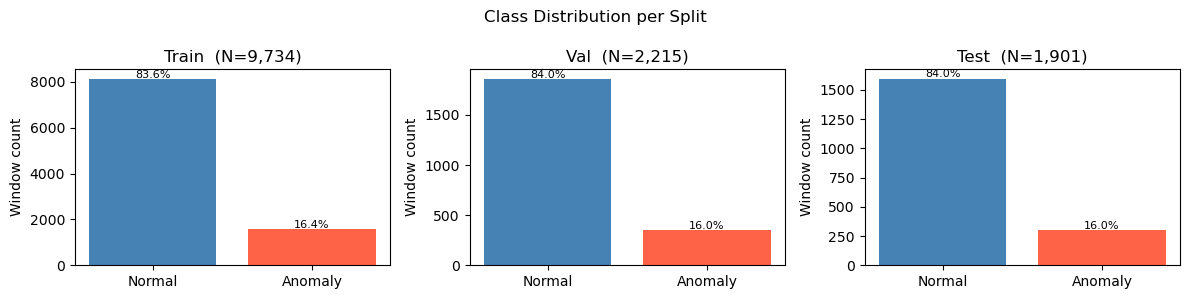

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3))
split_names = ['Train', 'Val', 'Test']
for ax, (name, y_s) in zip(axes, zip(split_names, [y_train, y_val, y_test])):
    counts = [(y_s == 0).sum(), (y_s == 1).sum()]
    bars = ax.bar(['Normal', 'Anomaly'], counts, color=['steelblue', 'tomato'])
    ax.set_title(f'{name}  (N={len(y_s):,})')
    ax.set_ylabel('Window count')
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{c/len(y_s)*100:.1f}%', ha='center', fontsize=8)
plt.suptitle('Class Distribution per Split')
plt.tight_layout()
plt.show()

In [4]:
out_path = DATA_DIR / 'rover_windows.npz'
np.savez_compressed(
    out_path,
    X_train_w10=X_train_w10, X_val_w10=X_val_w10, X_test_w10=X_test_w10,
    X_train_w20=X_train_w20, X_val_w20=X_val_w20, X_test_w20=X_test_w20,
    X_train_w50=X_train_w50, X_val_w50=X_val_w50, X_test_w50=X_test_w50,
    y_train=y_train, y_val=y_val, y_test=y_test,
    Xfft_train=Xfft_train, Xfft_val=Xfft_val, Xfft_test=Xfft_test,
    fft_col_names=np.array(fft_col_names),
    sensor_col_names=np.array(SENSOR_COLS),
)

fsize_mb = out_path.stat().st_size / 1e6
print(f'Saved to: {out_path.resolve()}')


Saved to: /home/lhy/ingen_ml/hongyu-ingen-ml-analyst/data/rover_windows.npz


## 2. MDP & Offline-RL Transition Table

The Aido Rover patrol task is modelled as a Markov Decision Process. Unlike Section 1 (which reuses the
canonical `continue`-policy detection stream), the transition table is generated by rolling a scripted
behaviour policy through the shared world core (`RoverWorld`, `blockages=True`) — actions genuinely
affect dynamics (reroute changes the branch taken, slow reduces fault-trigger probability), so `(s, a, r, s')`
is a valid interactive rollout, not an offline relabelling of a fixed trace. This is the same core the W05
Gymnasium env will wrap, so offline data and the online env share identical dynamics.

| Parameter | Value |
|-----------|-------|
| Map / hazard | `MAP_SEED=6`, `HAZARD=0.05` (same map as the W2 detection stream) |
| Discount γ | 0.99 |
| Decision rate | 100 ms (10 Hz, matches Aido Rover stream) |
| State dim | 9 scalar features |
| Action space | 5 discrete |
| Episode structure | multiple episodes (different blockage/fault seeds, same map), each capped at one full 960 m loop, chained to ~48,000 rows |

Full design rationale in `reports/W02_RL_scaffold.md`.

### 2.1 State Space  $\mathbf{s} \in \mathbb{R}^9$

Compact feature vector computed from the last `WINDOW` (=50) timesteps at each decision point,
plus the world core's `info` dict for position/blockage awareness.

| # | Feature | Source | Description |
|---|---------|--------|-------------|
| 0 | torque_mean | torque_0–3, window mean | Average wheel effort (Nm) |
| 1 | torque_max | torque_0–3, window max | Peak torque — stress indicator |
| 2 | torque_std | torque_0–3, window std | Torque variability |
| 3 | lidar_mean | lidar_distance, window mean  | Mean obstacle proximity |
| 4 | soc_slope | battery_soc, (last − first)/WINDOW | Discharge rate over the look-back window (%/step) |
| 5 | battery_soc | battery_soc, current | Remaining energy (%) |
| 6 | route_progress | info[route_progress] | Fraction of the main patrol loop completed (0–1) |
| 7 | next_main_block_dist | info[next_main_block_dist] | Distance (m) to the next blockage if continuing on the main route |
| 8 | branch_block_dist | info[branch_block_dist] | Distance (m) to the next blockage if rerouting onto the branch |

Absolute GPS is excluded from the anomaly-classifier features to avoid position-leakage(fixed terrain →
faults at fixed coordinates). route_progress + the two block distances replace it as the position summary.

In [5]:
from collections import deque

STATE_COLS = ['torque_mean', 'torque_max', 'torque_std', 'lidar_mean', 'soc_slope',
              'battery_soc', 'route_progress', 'next_main_block_dist', 'branch_block_dist']


def extract_state(tb: deque, lb: deque, sb: deque, info: dict) -> dict:
    """9-D state vector from rolling window buffers (torque, lidar, soc) + world-core info."""
    tarr = np.array(tb)  # [WINDOW, 4]
    return {
        'torque_mean': float(tarr.mean()),
        'torque_max':  float(tarr.max()),
        'torque_std':  float(tarr.std()),
        'lidar_mean':  float(np.mean(lb)),
        'soc_slope':   float((sb[-1] - sb[0]) / len(sb)),
        'battery_soc': float(sb[-1]),
        'route_progress':       float(info['route_progress']),
        'next_main_block_dist': float(info['next_main_block_dist']),
        'branch_block_dist':    float(info['branch_block_dist']),
    }


### 2.2 Action Space  $a \in \{0,1,2,3,4\}$

| ID | Name | Operational effect in RoverWorld |
|----|------|--------------------|
| 0 | continue | Normal speed, route unchanged |
| 1 | slow | Speed ×0.5, and scales down the fault-trigger probability (real slip compensation, not just energy saving) |
| 2 | reroute | Take the branch at the next node instead of the main edge (around a blockage) |
| 3 | raise-alert | No motion effect in the physics core (wrapper concern in W05); logged as the detection/escalation response |
| 4 | return-to-base | No motion effect in the core; episode ends (mission abort) |

### 2.3 Reward Function  $R(s, a)$

Three conditioning variables beyond `(label, action)` close gaps a pure lookup table would leave exploitable
once blockages and terrain-driven risk are in play: whether the rover is currently halted, whether the
main route ahead is actually blocked, and whether it is currently on high-slip terrain (window
`torque_mean` above a threshold that isolates wet-grass/mud from asphalt/gravel/dry-grass — calibrated in 2.4
below).

| Ground truth | Action | Reward | Note |
|---|---|---|---|
| Normal, not halted | continue (0) | +1.0 | productive patrol |
| Normal, halted | continue (0) | −0.5 | sitting at a blockage doing nothing is not productive — closes the "idle at a block still pays +1.0" exploit |
| Normal, low-slip terrain | slow (1) | −0.1 | unnecessary caution |
| Normal, high-slip terrain | slow (1) | 0.0 | justified proactive slow-down (real slip risk), not penalised |
| Normal, main route clear | reroute (2) | −0.3 | unwarranted path change |
| Normal, main route blocked ahead | reroute (2) | 0.0 | a justified detour is not penalised |
| Normal | raise-alert (3) | −1.5 | false alarm |
| Normal | return-to-base (4) | −3.0 | unwarranted mission abort |
| Anomaly | continue (0) | −5.0 | dangerous miss (safety penalty) |
| Anomaly | slow (1) | +1.5 | correct response — `slow` has a real fault-mitigating effect in the world core (↓ trigger probability); rewarded above `reroute`, which has none for a self-fault |
| Anomaly | reroute (2) | 0.0 | ineffective against a self-fault (torque/traction issue, not a path obstruction) — no longer rewarded as if it were |
| Anomaly | raise-alert (3) | +5.0 | correct detection & escalation |
| Anomaly | return-to-base (4) | +3.0 | safe but costly response |
| Any | Any | −0.05 per step | energy cost, always applied |


In [6]:
LOW_SOC         = 20.0   # %, matches the Aido Rover auto-dock threshold
ENERGY_PER_STEP = 0.05

NORMAL_REWARD  = {0: 1.0, 1: -0.1, 2: -0.3, 3: -1.5, 4: -3.0}
ANOMALY_REWARD = {0: -5.0, 1: 1.5, 2: 0.0, 3: 5.0, 4: 3.0}


def compute_reward(label: int, action: int, halted: bool, main_blocked: bool,
                    rough_terrain: bool, battery_soc: float) -> float:
    if label == 0:
        if action == 0 and halted:
            base = -0.5                     # idle at a blockage, not productive
        elif action == 2 and main_blocked:
            base = 0.0                      # justified detour, not penalised
        elif action == 1 and rough_terrain:
            base = 0.0                      # justified proactive slow-down, not penalised
        else:
            base = NORMAL_REWARD[action]
    else:
        base = ANOMALY_REWARD[action]
    shaping = 2.0 if (battery_soc < LOW_SOC and action == 4) else 0.0
    return base + shaping - ENERGY_PER_STEP

 
print('Reward table')
print()
print('(label, action -> base reward, before conditioning and shaping):')
for lbl, table in [(0, NORMAL_REWARD), (1, ANOMALY_REWARD)]:
    for act, r in table.items():
        print(f'  label={lbl}  action={act} ({ACTION_NAMES[act]:16s})  reward={r:+.1f}')
    print()
print('Conditioning: normal+continue+halted -> -0.5 (not +1.0)')
print('              normal+reroute+main_blocked -> 0.0 (not -0.3)')
print('              normal+slow+rough_terrain -> 0.0 (not -0.1)')
print(f'Shaping: +2.0 when battery_soc < {LOW_SOC}% and action -> return-to-base')

Reward table

(label, action -> base reward, before conditioning and shaping):
  label=0  action=0 (continue        )  reward=+1.0
  label=0  action=1 (slow            )  reward=-0.1
  label=0  action=2 (reroute         )  reward=-0.3
  label=0  action=3 (raise-alert     )  reward=-1.5
  label=0  action=4 (return-to-base  )  reward=-3.0

  label=1  action=0 (continue        )  reward=-5.0
  label=1  action=1 (slow            )  reward=+1.5
  label=1  action=2 (reroute         )  reward=+0.0
  label=1  action=3 (raise-alert     )  reward=+5.0
  label=1  action=4 (return-to-base  )  reward=+3.0

Conditioning: normal+continue+halted -> -0.5 (not +1.0)
              normal+reroute+main_blocked -> 0.0 (not -0.3)
              normal+slow+rough_terrain -> 0.0 (not -0.1)
Shaping: +2.0 when battery_soc < 20.0% and action -> return-to-base


### 2.4 Scripted Behaviour Policy

Priority-ordered rule table (first matching rule wins), plus 5% ε-explore over `{continue, slow, reroute,
raise-alert}` for BC action-space coverage — exploration never randomly samples `return-to-base`, so
an episode's end is always a genuine scripted decision (low battery / unresolved full block), never a
1-in-20 coin flip that happened to land on "abort mission":

| Priority | Condition | Action |
|---|---|---|
| 1 | `battery_soc < 20%` | `return-to-base` (episode ends) |
| 2 | `stuck_counter ≥ 80` (full block unresolved 8s) | `return-to-base` (episode ends, forced) |
| 3 | `halted` AND main+branch both blocked ahead | `raise-alert` (report double blockage) |
| 4 | `anomaly_label == 1` (ground truth — competent expert) | `raise-alert` |
| 5 | main route blocked ahead (< 150 m) AND branch clear | `reroute` |
| 6 | `torque_mean > 30 Nm` (wet-grass/mud only — high slip risk) | `slow` |
| 7 | default | `continue` |

`raise-alert` on a real fault uses the ground-truth `anomaly_label` at generation time, not an observable
torque-based proxy: torque statistics are terrain-confounded — a
torque-threshold trigger, measured against the actual blockage-enabled rollout, produces a ~27% false-alert
rate on normal rough-terrain windows. The scripted policy is a behaviour-cloning expert (ground truth is
available at generation time; a deployment classifier would not have it), matching the world-core design's
"alert on fault" intent.

Reroute trigger = 150 m: `next_main_block_dist` reports the full remaining distance to a blockage along a
hypothetical path, available as soon as the blockage is anywhere on that path — not only once the rover is
physically close. The reroute decision must be resolved before the rover commits to entering the blocked
edge, while it may still be a full edge-length away (branch edges run 53–160 m, with blocks typically 60–90 m
into them), so the trigger distance is set generously — 150 m, near the sensor's lookahead limit. Validated
against the actual rollout: halted fraction ≈0%, vs. 79% for a rover with no reroute logic engaged at all.

Slow trigger = window `torque_mean` > 30 Nm, isolating wet-grass/mud, and the world core gives `slow` a real mitigating effect (↓ fault-trigger probability via
`speed_factor`). dry_grass sits at 25.2–27.5 Nm while wet_grass starts at 36.9 Nm — a clean
~9 Nm gap; 30 Nm sits in it, so `slow` triggers only for the two genuinely high-slip terrains. Checked after the reroute
condition and before the default, so it never overrides a real blockage response.

Alert vs return-to-base on a full block are the same condition, escalated by time, not two independent
rules: blockages are static (they never clear in this core), so a full block is a dead end for a priority-only
policy. Steps 1–79 of being stuck there are logged as `raise-alert`; step 80 forces `return-to-base` and ends
the episode (world resets with a new blockage/fault draw). This bounds how much of an episode's step budget
a persistent full block can consume.


In [7]:
NEAR                 = 150.0   # m, reroute / full-block trigger distance (empirically calibrated, see above)
STUCK_TIMEOUT        = 80       # steps, unresolved full block -> forced return-to-base
ROUGH_TERRAIN_TORQUE = 30.0     # Nm, window torque_mean threshold isolating wet-grass/mud (high slip) from
                                 # dry-grass/gravel/asphalt (see rationale above)

# Priority-ordered rule table — first matching rule wins. Each row: (description, condition, action, forced_done).
POLICY_RULES = [
    ('battery_soc < LOW_SOC',
     lambda s, l, h, st: s['battery_soc'] < LOW_SOC,
     4, True),
    ('stuck_ctr >= STUCK_TIMEOUT',
     lambda s, l, h, st: st >= STUCK_TIMEOUT,
     4, True),
    ('halted AND main+branch both blocked',
     lambda s, l, h, st: h and s['next_main_block_dist'] < NEAR and s['branch_block_dist'] < NEAR,
     3, False),
    ('anomaly_label == 1 (ground truth)',
     lambda s, l, h, st: l == 1,
     3, False),
    ('main blocked AND branch clear',
     lambda s, l, h, st: s['next_main_block_dist'] < NEAR and s['branch_block_dist'] >= NEAR,
     2, False),
    ('torque_mean > ROUGH_TERRAIN_TORQUE',
     lambda s, l, h, st: s['torque_mean'] > ROUGH_TERRAIN_TORQUE,
     1, False),
]


def scripted_policy(state: dict, label: int, halted: bool, stuck_ctr: int) -> tuple:
    """Priority-ordered behaviour policy — first matching POLICY_RULES row wins. Returns (action, forced_done)."""
    for _, condition, action, forced_done in POLICY_RULES:
        if condition(state, label, halted, stuck_ctr):
            return action, forced_done
    return 0, False                                  # default: continue



### 2.5 Transition Dataset Generation

Roll the scripted policy through the world core across multiple episodes (different blockage/fault
seeds, same `MAP_SEED=6` map) until ~48,000 `(s, a, r, s', done)` rows are logged. Multiple episodes are
necessary, not a stylistic choice: each episode's blockage layout is one random draw, and a "both branches
blocked" configuration only occurs in a fraction of draws (4/10 seeds tried during calibration) — a dataset
budget of only 1–2 full-loop episodes risks never exercising the full-block escalation path or the low-battery
path at all. ~48,000 rows (≈5 full-loop episodes worth, before accounting for any early aborts) is sized to
give a realistic chance of seeing both at least a few times.

Episode mechanics:
- Episode cap = 9,600 steps (one full 960 m main-loop circuit), enforced as a real episode boundary —
  once reached, the current episode ends (done=True) and the next episode draws a fresh blockage/fault seed.
  Episodes can also end earlier for a genuine reason (low battery / unresolved full block).
- Initial battery_soc is randomised per episode — first episode starts at 100% (canonical full-charge
  patrol); subsequent episodes draw `Uniform(40, 100)`, reflecting a rover fleet dispatching with a range of
  charge levels (not always full) rather than an unrealistic near-empty start. This is set directly on the
  `RoverWorld` instance after `reset()` (`w.soc = ...`) — no core code changes. Without this, `battery_soc`
  never approaches the 20% auto-dock threshold within one 960 m loop, and `return-to-base` would only ever
  fire via the stuck-timeout path.
- `episode_id` is logged as a column so downstream (W05) can compute per-episode return.
- ε-explore never samples `return-to-base` (see 2.4) — every `done=True` row reflects a genuine scripted
  decision (low battery, unresolved full block, or a completed loop), not a random exploratory draw.

CSV columns: `episode_id` · `s_*` (9 state features) · `action` · `action_name` · `reward` · `done` ·
`actual_label` · `ns_*` (9 next-state features).

In [8]:
MAP_SEED       = 6
HAZARD         = 0.05
TOTAL_TARGET   = 48000           # ~5 full-loop episodes worth -> enough seed diversity to exercise
                                  # both the full-block and low-battery branches at least a few times
EP_CAP         = 9600            # one full 960 m main-loop circuit
SOC_INIT_RANGE = (40.0, 100.0)
EPS            = 0.05
BASE_SEED      = SEED            # 42


def generate_transitions(total_target=TOTAL_TARGET, base_seed=BASE_SEED):
    rng_exp = np.random.default_rng(base_seed + 777)
    rows, ep, total = [], 0, 0

    while total < total_target:
        w = RoverWorld(hazard_intensity=HAZARD, seed=base_seed + ep, total_steps=EP_CAP,
                        map_seed=MAP_SEED, blockages=True)
        w.soc = 100.0 if ep == 0 else float(rng_exp.uniform(*SOC_INIT_RANGE))

        tb, lb, sb = deque(maxlen=WINDOW), deque(maxlen=WINDOW), deque(maxlen=WINDOW)
        action, stuck_ctr, ep_len, pending = 0, 0, 0, None

        while total < total_target:
            r = w.step(action)
            tb.append([r['torque_0'], r['torque_1'], r['torque_2'], r['torque_3']])
            lb.append(r['lidar_distance']); sb.append(r['battery_soc'])
            info = r['info']
            ep_len += 1

            if len(tb) < WINDOW:
                action = 0
                continue

            state = extract_state(tb, lb, sb, info)
            label = int(r['anomaly_label'])
            halted = bool(info['halted'])
            main_blocked   = state['next_main_block_dist'] < NEAR
            branch_blocked = state['branch_block_dist']    < NEAR
            rough_terrain  = state['torque_mean'] > ROUGH_TERRAIN_TORQUE
            stuck_ctr = stuck_ctr + 1 if (halted and main_blocked and branch_blocked) else 0

            scripted_action, forced_done = scripted_policy(state, label, halted, stuck_ctr)
            next_action = scripted_action
            if not forced_done and rng_exp.random() < EPS:
                next_action = int(rng_exp.integers(0, 4))    # explore continue/slow/reroute/alert only —
            cap_done = ep_len >= EP_CAP                       # one full loop completed -> new seed next episode
            done = forced_done or (scripted_action == 4) or cap_done
            reward = compute_reward(label, next_action, halted, main_blocked, rough_terrain, state['battery_soc'])

            if pending is not None:
                p_state, p_action, p_reward, p_label = pending
                row = {'episode_id': ep, **{f's_{k}': v for k, v in p_state.items()},
                       'action': p_action, 'action_name': ACTION_NAMES[p_action],
                       'reward': p_reward, 'done': False, 'actual_label': p_label,
                       **{f'ns_{k}': v for k, v in state.items()}}
                rows.append(row); total += 1

            if done:
                row = {'episode_id': ep, **{f's_{k}': v for k, v in state.items()},
                       'action': next_action, 'action_name': ACTION_NAMES[next_action],
                       'reward': reward, 'done': True, 'actual_label': label,
                       **{f'ns_{k}': v for k, v in state.items()}}   # terminal: no successor this episode
                rows.append(row); total += 1
                pending = None
                break

            pending = (state, next_action, reward, label)
            action = next_action

        ep += 1

    return pd.DataFrame(rows), ep


transitions, n_episodes = generate_transitions()
print(f'Transitions: {len(transitions):,} rows x {transitions.shape[1]} cols across {n_episodes} episodes')
transitions.head(3).round(4)

Transitions: 48,000 rows x 24 cols across 8 episodes


,episode_id,s_torque_mean,s_torque_max,s_torque_std,s_lidar_mean,s_soc_slope,s_battery_soc,s_route_progress,s_next_main_block_dist,s_branch_block_dist,...,actual_label,ns_torque_mean,ns_torque_max,ns_torque_std,ns_lidar_mean,ns_soc_slope,ns_battery_soc,ns_route_progress,ns_next_main_block_dist,ns_branch_block_dist
0,0,5.9210,7.4244,0.4764,23.1190,-0.003,99.8447,0.0052,200.0,200.0,...,0,5.9289,7.4244,0.4859,23.1193,-0.003,99.8415,0.0053,200.0,200.0
1,0,5.9289,7.4244,0.4859,23.1193,-0.003,99.8415,0.0053,200.0,200.0,...,0,5.9401,7.4244,0.4841,26.6589,-0.003,99.8384,0.0054,200.0,200.0
2,0,5.9401,7.4244,0.4841,26.6589,-0.003,99.8384,0.0054,200.0,200.0,...,0,5.9269,7.4244,0.4883,26.6609,-0.003,99.8353,0.0055,200.0,200.0


=== Transition Statistics ===

Action distribution (per-step — a sustained action, e.g. rerouting through an approach zone or
alerting through a fault duration, is counted once per row, not once per event):
  0 (continue        ): 24,078  ( 50.2%)
  1 (slow            ):  7,737  ( 16.1%)
  2 (reroute         ):  7,224  ( 15.0%)
  3 (raise-alert     ):  8,956  ( 18.7%)
  4 (return-to-base  ):      5  (  0.0%)

Event-level counts (action onsets — how many distinct times each action was chosen):
  0 (continue        ): 1,303 events
  1 (slow            ):   929 events
  2 (reroute         ):   836 events
  3 (raise-alert     ): 1,034 events
  4 (return-to-base  ):     5 events

Reward stats:
count    48000.000
mean         1.276
std          1.767
min         -5.050
25%         -0.050
50%          0.950
75%          0.950
max          4.950

Episodes: 8
Mean return per episode: 7653.7

Anomaly response rate: 8240/8549 = 96.4%
(raise-alert or return-to-base when actual_label=1)

Episodes r

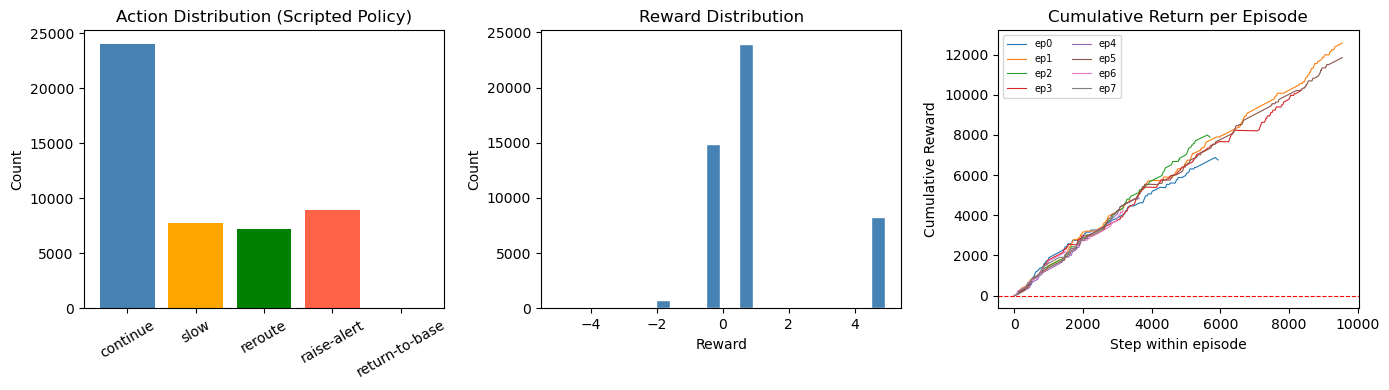

In [9]:
print('=== Transition Statistics ===\n')

action_counts = transitions['action'].value_counts().sort_index()
print('Action distribution (per-step — a sustained action, e.g. rerouting through an approach zone or\n'
      'alerting through a fault duration, is counted once per row, not once per event):')
for a, c in action_counts.items():
    print(f'  {a} ({ACTION_NAMES[a]:16s}): {c:>6,}  ({c/len(transitions)*100:5.1f}%)')

# Event-level counts: an "onset" is a row whose action differs from the previous row within the same
# episode (episode-start rows always count as an onset, since groupby().shift() is NaN there).
onset = transitions['action'] != transitions.groupby('episode_id')['action'].shift(1)
event_counts = transitions.loc[onset, 'action'].value_counts().sort_index()
print('\nEvent-level counts (action onsets — how many distinct times each action was chosen):')
for a, c in event_counts.items():
    print(f'  {a} ({ACTION_NAMES[a]:16s}): {c:>5,} events')

print(f'\nReward stats:\n{transitions["reward"].describe().round(3).to_string()}')
print(f'\nEpisodes: {transitions["episode_id"].nunique()}')
print(f'Mean return per episode: {transitions.groupby("episode_id")["reward"].sum().mean():.1f}')

anoms = transitions[transitions['actual_label'] == 1]
correct = anoms['action'].isin([3, 4]).sum()
print(f'\nAnomaly response rate: {correct}/{len(anoms)} = {correct/len(anoms)*100:.1f}%')
print('(raise-alert or return-to-base when actual_label=1)')

soc_min_per_ep = transitions.groupby('episode_id')['s_battery_soc'].min()
print(f'\nEpisodes reaching battery_soc < {LOW_SOC}%: {(soc_min_per_ep < LOW_SOC).sum()} / {len(soc_min_per_ep)}')
print(f'return-to-base rows: {(transitions["action"] == 4).sum()}')

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

colors = ['steelblue', 'orange', 'green', 'tomato', 'purple']
axes[0].bar([ACTION_NAMES[a] for a in range(5)],
            [action_counts.get(a, 0) for a in range(5)], color=colors)
axes[0].set_title('Action Distribution (Scripted Policy)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=30)

axes[1].hist(transitions['reward'], bins=20, color='steelblue', edgecolor='white', rwidth=0.85)
axes[1].set_title('Reward Distribution')
axes[1].set_xlabel('Reward')
axes[1].set_ylabel('Count')

for ep_id, grp in transitions.groupby('episode_id'):
    axes[2].plot(grp['reward'].cumsum().values, lw=0.8, label=f'ep{ep_id}')
axes[2].axhline(0, color='red', ls='--', lw=0.8)
axes[2].set_title('Cumulative Return per Episode')
axes[2].set_xlabel('Step within episode')
axes[2].set_ylabel('Cumulative Reward')
axes[2].legend(fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

In [10]:
# Save rover_transitions.csv
csv_path = DATA_DIR / 'rover_transitions.csv'
transitions.to_csv(csv_path, index=False)
fsize_kb = csv_path.stat().st_size / 1e3
print(f'Saved: {csv_path.resolve()}, {len(transitions):,} rows)')

Saved: /home/lhy/ingen_ml/hongyu-ingen-ml-analyst/data/rover_transitions.csv, 48,000 rows)


## Summary

| Artefact | Shape / Size | Downstream notebook |
|----------|-------------|---------------------|
| `data/rover_windows.npz` | `X_{train,val,test}_w{10,20,50}` [N, W, 11] raw (9 sensor + 2 physical) + `Xfft_{train,val,test}` [N, 25] FFT view (w=50) | W03 Sequence Models |
| `data/rover_transitions.csv` | ~48,000 rows × 24 cols (incl. `episode_id`) | W05 Offline RL & BC |
| `rl/mdp_schema.md` | — | W05 Gymnasium env spec |
| `reports/W02_RL_scaffold.md` | design rationale and calibration evidence | reference for W05–W06 |

Design choices (Section 1):
- Three window sizes (`WINDOW_SIZES=[10,20,50]`) are built from the same purged anchor rows, so the W03 latency-vs-window-size sweep isolates window-size effects rather than confounding them with a different row set; 50 (5 s) matches the FFT window in `W02_Preprocessing_Pipeline`.
- `STRIDE=1` (0.1 s) maximises training samples; Phase B models can subsample if compute is a concern.
- The train/val/test split and the purge rule (each block's first 50 rows excluded as anchors) come from `rover_stratified_block_split.csv`.
- The FFT view reuses the exact `fft_features` extractor from Week 2 preprocessing, row-aligned with the raw tensors.
- Two cross-channel physical features (`inter_wheel_std`, `stall_ratio`, from `shared_modules/features.py`) are added as extra raw channels (9 → 11).

Design choices (Section 2):
- Transitions are generated by an interactive rollout through the shared world core (blockages ON), not an offline relabelling of a fixed trace — actions genuinely affect dynamics, so it is valid for BC/offline RL.
- 9-D state (torque stats + LiDAR + SoC + SoC-slope + position/blockage summary).
- Reward is conditioned on `halted`, `main_blocked`, and a high-slip-terrain flag in addition to `(label, action)` to close exploits a flat lookup table would otherwise leave (idle-at-a-block still scoring +1.0; a justified reroute or a justified proactive slow-down penalised the same as an unwarranted one). Full rationale: `reports/W02_RL_scaffold.md`.
- The scripted policy is a priority-ordered rule table (`POLICY_RULES`, mirroring the reward table's style) with an explicit `slow` branch (window `torque_mean` > 30 Nm, isolating wet-grass/mud specifically, per the product docs). Event-level (not just per-step) action counts are reported alongside the per-step distribution to avoid misreading sustained states as rare events.
- Multi-episode generation (each capped at one full loop, ~48,000 rows total) with per-episode SoC randomisation is required for the dataset to actually exercise the full-block and low-battery branches; a single continuous episode or an unenforced cap does not.
- ε-explore samples only `{continue, slow, reroute, raise-alert}`, never `return-to-base` — episode boundaries are always genuine scripted decisions, never a random exploratory artifact.
- The scripted policy is intentionally suboptimal (privileged-label alerting, no learned trade-offs); RL agents in Phase C are evaluated against its cumulative return as a baseline.